In [ ]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

**Globals**

In [ ]:
import random
random.seed(2026)
np.random.seed(2026)
torch.manual_seed(2026)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


**Load Dataset**

In [ ]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/fancyzhx/ag_news/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/fancyzhx/ag_news/" + splits["test"])
print(df_train.shape)
print(df_test.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(120000, 2)
(7600, 2)


# Task 1: LSTM Classifier Trained From Scratch

**1. Data split**

In [ ]:
from sklearn.model_selection import train_test_split
train_set, val_set = train_test_split(df_train, test_size = 0.1, random_state = 2026, stratify = df_train.iloc[:,-1])

**2. Tokenization and vocabulary (word-level)**

In [ ]:
def tokenid_gen():
  n = 0
  while True:
    yield n
    n += 1

In [ ]:
import nltk
nltk.download('punkt_tab')

vocabulary = {}
for text in train_set["text"]:
  for token in nltk.word_tokenize(text.lower(), language="english", preserve_line=False):
    if not token in vocabulary.keys():
      vocabulary[token] = 1
    else:
      vocabulary[token] += 1
print(len(vocabulary))

id_stream = tokenid_gen()
vocabulary = {token: next(id_stream) for token in vocabulary.keys() if vocabulary.get(token, 0) > 1}
for special_kwd in ["PAD", "UNK"]:
  if special_kwd in vocabulary:
    raise RuntimeError(f"Keyword value {special_kwd} overlaps with existing word in vocabulary")
vocabulary |= {token: next(id_stream) for token in ["PAD", "UNK"]}
print(len(vocabulary))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


95146
51800


**3. Padding and LSTM input handling**

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

MAX_SEQ_LEN = 128

class PaddedDataset(Dataset):
    def __init__(self, x, y, vocab):
        self.x = x
        self.y = y
        self.vocab = vocab

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        text = self.x.iloc[idx]["text"]
        tokenized_text = nltk.word_tokenize(text.lower(), language="english", preserve_line=False)
        token_ids = [self.vocab.get(token, self.vocab["UNK"]) for token in tokenized_text[:MAX_SEQ_LEN]]
        x_tensor = torch.tensor(token_ids, dtype=torch.long)
        return x_tensor, self.y.iloc[idx]

def pad_and_collate(tups, vocabulary):
    tokens = [tup[0] for tup in tups]
    labels = torch.tensor([tup[1] for tup in tups], dtype=torch.long)
    data_padded = pad_sequence(tokens, batch_first=True, padding_value=vocabulary["PAD"])
    return data_padded, labels


In [ ]:
BATCH_SIZE = 64

train_x, train_y = train_set.iloc[:,:-1], train_set.iloc[:,-1]
train_dataset = PaddedDataset(train_x, train_y, vocabulary)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=lambda x: pad_and_collate(x, vocabulary), shuffle=True)

val_x, val_y = val_set.iloc[:,:-1], val_set.iloc[:,-1]
val_dataset = PaddedDataset(val_x, val_y, vocabulary)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=lambda x: pad_and_collate(x, vocabulary), shuffle=False)

**4. Model architecture**

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Supports LSTM, GRU, and Vanilla RNN for arch
class RNNClassifier(nn.Module):
    def __init__(self, vocabulary, embedding_dim=128, hidden_size=256, num_layers=1, dropout=0.1, bidirectional=True, arch="LSTM"):
        super(RNNClassifier, self).__init__()
        self.pad_idx = vocabulary["PAD"]
        self.embedding = nn.Embedding(len(vocabulary), embedding_dim, padding_idx=self.pad_idx)
        self.rnn = {
            "LSTM" : nn.LSTM(
                embedding_dim, hidden_size, num_layers,
                dropout=dropout if num_layers > 1 else 0,
                bidirectional=bidirectional,
                batch_first=True
            ),
            "GRU": nn.GRU(
                embedding_dim, hidden_size, num_layers,
                dropout=dropout if num_layers > 1 else 0,
                bidirectional=bidirectional,
                batch_first=True
            ),
            "Vanilla": nn.RNN(
                embedding_dim, hidden_size, num_layers,
                dropout=dropout if num_layers > 1 else 0,
                bidirectional=bidirectional,
                batch_first=True
            )
        }.get(arch)
        self.linear = nn.Linear(hidden_size * (1 + int(bidirectional)), 4)

    def forward(self, x):
        # x: (batch, seq_len)
        s = self.embedding(x)
        s, _ = self.rnn(s)

        # Masked mean pooling — ignore PAD positions
        mask = (x != self.pad_idx).unsqueeze(2).float()
        sums = (s * mask).sum(dim=1)
        num_elmts = mask.sum(dim=1).clamp(min=1)
        s = sums / num_elmts

        return self.linear(s)

In [ ]:
model = RNNClassifier(vocabulary, dropout=0.3, num_layers=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

RNNClassifier(
  (embedding): Embedding(51800, 128, padding_idx=51798)
  (rnn): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear): Linear(in_features=512, out_features=4, bias=True)
)

Total parameters: 8,999,940
Trainable parameters: 8,999,940


**5. Training**

In [ ]:
def train(model, optimizer, criterion, epochs, train_dataloader, val_dataloader):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    start_time = datetime.datetime.now()

    print('Starting training...')
    print(f'Batches per epoch: {len(train_dataloader)}')

    for epoch in range(epochs):
        model.train()

        epoch_loss = 0.0
        correct = 0

        for (sequences, labels) in train_dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()

        avg_train_loss = epoch_loss / len(train_dataloader)
        avg_train_accuracy = 100 * correct / len(train_dataset)

        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_accuracy)

        model.eval()
        epoch_loss = 0.0
        correct = 0
        with torch.no_grad():
            for sequences, labels in val_dataloader:
                sequences = sequences.to(device)
                labels = labels.to(device)

                outputs = model(sequences)
                loss = criterion(outputs, labels)

                epoch_loss += loss.item()
                _, predicted = torch.max(outputs, dim=1)
                correct += (predicted == labels).sum().item()

            avg_val_loss = epoch_loss / len(val_dataloader)
            avg_val_accuracy = 100 * correct / len(val_dataset)

            val_losses.append(avg_val_loss)
            val_accuracies.append(avg_val_accuracy)

        print(f"Epoch {epoch + 1} - Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_accuracy:5.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_accuracy:5.2f}%")

    print('\nTraining complete!')
    print(f"Total training time: {datetime.datetime.now() - start_time}")
    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 6

train_losses, train_accuracies, val_losses, val_accuracies = train(model, optimizer, criterion, num_epochs, train_dataloader, val_dataloader)

Starting training...
Batches per epoch: 1688
Epoch 1 - Train Loss: 0.4206, Train Acc: 84.67%, Val Loss: 0.2860, Val Acc: 90.23%
Epoch 2 - Train Loss: 0.2140, Train Acc: 92.61%, Val Loss: 0.2486, Val Acc: 91.47%
Epoch 3 - Train Loss: 0.1446, Train Acc: 95.01%, Val Loss: 0.2429, Val Acc: 92.19%
Epoch 4 - Train Loss: 0.0938, Train Acc: 96.70%, Val Loss: 0.2512, Val Acc: 92.09%
Epoch 5 - Train Loss: 0.0568, Train Acc: 97.98%, Val Loss: 0.3126, Val Acc: 91.38%
Epoch 6 - Train Loss: 0.0347, Train Acc: 98.78%, Val Loss: 0.3978, Val Acc: 91.62%

Training complete!
Total training time: 0:09:27.678618


In [ ]:
def plot_learning_curves(train_losses, val_losses, val_accuracies, arch):
    # Plot LSTM learning curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train Loss')
    axes[0].plot(range(1, num_epochs + 1), val_losses, marker='o', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{arch}: Loss vs Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(1, num_epochs + 1), val_accuracies, marker='o', color='green', label='Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{arch}: Validation Accuracy vs Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

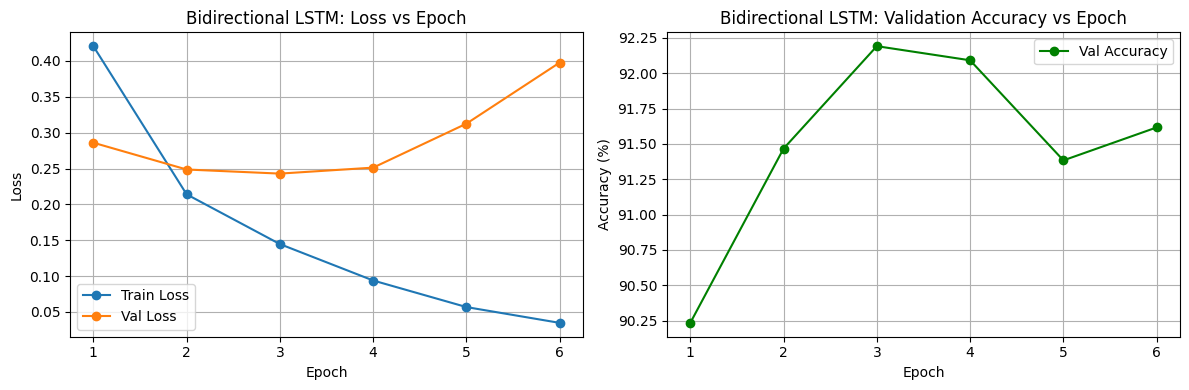

In [ ]:
plot_learning_curves(train_losses, val_losses, val_accuracies, "Bidirectional LSTM")

**6. Test Model**

In [ ]:
def test_model(model, test_dataframe):
    test_correct = 0
    test_loss = 0.0

    test_x = test_dataframe.iloc[:,:-1]
    test_y = test_dataframe.iloc[:,-1]

    test_dataset = PaddedDataset(test_x, test_y, vocabulary)
    test_dataloader = DataLoader(test_dataset, 1, False, collate_fn=lambda x: pad_and_collate(x, vocabulary))

    wrong_predictions = []

    model.eval()
    with torch.no_grad():
        for i, (sequences, labels) in enumerate(test_dataloader):
            sequence = sequences.to(device)
            label = labels.to(device)

            output = model(sequence)

            loss = criterion(output, label)
            test_loss += loss.item()

            _, predicted = torch.max(output, dim=1)

            if predicted != label:
                wrong_predictions.append((test_x.iloc[i]["text"], test_y.iloc[i], predicted))
            else:
                test_correct += 1

    test_accuracy = 100 * test_correct / len(test_dataloader)
    avg_test_loss = test_loss / len(test_dataloader)
    return test_accuracy, avg_test_loss, wrong_predictions


In [ ]:
test_x = df_test.iloc[:,:-1]
test_y = df_test.iloc[:,-1]

test_dataset = PaddedDataset(test_x, test_y, vocabulary)
test_dataloader = DataLoader(test_dataset, 1, False, collate_fn=lambda x: pad_and_collate(x, vocabulary))

test_accuracy, avg_test_loss, wrong_predictions = test_model(model, df_test)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')
print("Wrong Predictions (10 displayed): \n")
for i in range(min(len(wrong_predictions), 10)):
  print(f"Text: {wrong_predictions[i][0]}\nTrue Label: {wrong_predictions[i][1]}\nPredicted Label: {wrong_predictions[i][2].item()}\n")

Test Loss: 0.3918
Test Accuracy: 91.70%
Wrong Predictions (10 displayed): 

Text: Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he expects. Winds will pick up, moist places will dry and flames will roar.
True Label: 3
Predicted Label: 1

Text: Rocking the Cradle of Life When did life begin? One evidential clue stems from the fossil records in Western Australia, although whether these layered sediments are biological or chemical has spawned a spirited debate. Oxford researcher, Nicola McLoughlin, describes some of the issues in contention.
True Label: 3
Predicted Label: 0

Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum o

**BONUS: Train & Test Unidirectional LSTM Model**

In [ ]:
model = RNNClassifier(vocabulary, dropout=0.3, num_layers=2, arch="LSTM", bidirectional=False).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

RNNClassifier(
  (embedding): Embedding(51800, 128, padding_idx=51798)
  (rnn): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (linear): Linear(in_features=256, out_features=4, bias=True)
)

Total parameters: 7,553,028
Trainable parameters: 7,553,028


Starting training...
Batches per epoch: 1688
Epoch 1 - Train Loss: 0.4406, Train Acc: 84.14%, Val Loss: 0.2929, Val Acc: 90.08%
Epoch 2 - Train Loss: 0.2279, Train Acc: 92.16%, Val Loss: 0.2542, Val Acc: 91.27%
Epoch 3 - Train Loss: 0.1571, Train Acc: 94.60%, Val Loss: 0.2468, Val Acc: 91.59%
Epoch 4 - Train Loss: 0.1034, Train Acc: 96.46%, Val Loss: 0.2832, Val Acc: 91.39%
Epoch 5 - Train Loss: 0.0638, Train Acc: 97.81%, Val Loss: 0.3306, Val Acc: 91.09%
Epoch 6 - Train Loss: 0.0405, Train Acc: 98.62%, Val Loss: 0.4170, Val Acc: 91.51%

Training complete!
Total training time: 0:05:58.532078


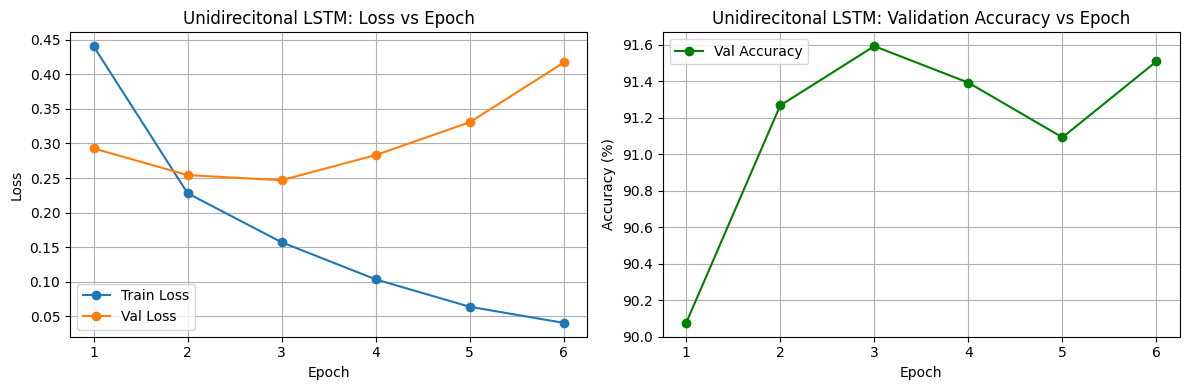

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, train_accuracies, val_losses, val_accuracies = train(model, optimizer, criterion, num_epochs, train_dataloader, val_dataloader)
plot_learning_curves(train_losses, val_losses, val_accuracies, "Unidirecitonal LSTM")

In [ ]:
test_accuracy, avg_test_loss, wrong_predictions = test_model(model, df_test)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')
print("Wrong Predictions (10 displayed): \n")
for i in range(min(len(wrong_predictions), 10)):
  print(f"Text: {wrong_predictions[i][0]}\nTrue Label: {wrong_predictions[i][1]}\nPredicted Label: {wrong_predictions[i][2].item()}\n")

Test Loss: 0.4460
Test Accuracy: 91.11%
Wrong Predictions (10 displayed): 

Text: Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he expects. Winds will pick up, moist places will dry and flames will roar.
True Label: 3
Predicted Label: 1

Text: Card fraud unit nets 36,000 cards In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - and estimates it saved 65m.
True Label: 3
Predicted Label: 2

Text: Super ant colony hits Australia A giant 100km colony of ants  which has been discovered in Melbourne, Australia, could threaten local insect species.
True Label: 3
Predicted Label: 2

Text: IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.
True Label: 3
Predicted Label

**BONUS: Train & Test GRU Model**

In [ ]:
model = RNNClassifier(vocabulary, dropout=0.3, num_layers=2, arch="GRU").to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

RNNClassifier(
  (embedding): Embedding(51800, 128, padding_idx=51798)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear): Linear(in_features=512, out_features=4, bias=True)
)

Total parameters: 8,408,068
Trainable parameters: 8,408,068


Starting training...
Batches per epoch: 1688
Epoch 1 - Train Loss: 0.4144, Train Acc: 84.84%, Val Loss: 0.2741, Val Acc: 90.45%
Epoch 2 - Train Loss: 0.2074, Train Acc: 92.82%, Val Loss: 0.2365, Val Acc: 92.13%
Epoch 3 - Train Loss: 0.1329, Train Acc: 95.34%, Val Loss: 0.2584, Val Acc: 91.84%
Epoch 4 - Train Loss: 0.0781, Train Acc: 97.36%, Val Loss: 0.2884, Val Acc: 91.58%
Epoch 5 - Train Loss: 0.0469, Train Acc: 98.41%, Val Loss: 0.3576, Val Acc: 91.26%
Epoch 6 - Train Loss: 0.0303, Train Acc: 98.98%, Val Loss: 0.3966, Val Acc: 91.13%

Training complete!
Total training time: 0:07:53.418025


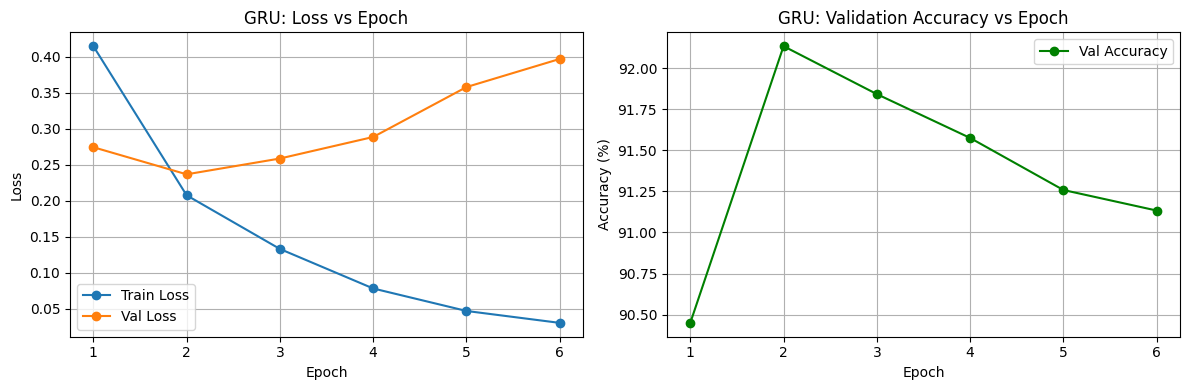

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, train_accuracies, val_losses, val_accuracies = train(model, optimizer, criterion, num_epochs, train_dataloader, val_dataloader)
plot_learning_curves(train_losses, val_losses, val_accuracies, "GRU")

In [ ]:
test_accuracy, avg_test_loss, wrong_predictions = test_model(model, df_test)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')
print("Wrong Predictions (10 displayed): \n")
for i in range(min(len(wrong_predictions), 10)):
  print(f"Text: {wrong_predictions[i][0]}\nTrue Label: {wrong_predictions[i][1]}\nPredicted Label: {wrong_predictions[i][2].item()}\n")

Test Loss: 0.4045
Test Accuracy: 91.45%
Wrong Predictions (10 displayed): 

Text: Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he expects. Winds will pick up, moist places will dry and flames will roar.
True Label: 3
Predicted Label: 0

Text: Card fraud unit nets 36,000 cards In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - and estimates it saved 65m.
True Label: 3
Predicted Label: 2

Text: IBM Chips May Someday Heal Themselves New technology applies electrical fuses to help identify and repair faults.
True Label: 3
Predicted Label: 2

Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. 

**BONUS: Train & Test Vanilla RNN Model**

In [ ]:
model = RNNClassifier(vocabulary, dropout=0.3, num_layers=2, arch="Vanilla").to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

RNNClassifier(
  (embedding): Embedding(51800, 128, padding_idx=51798)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear): Linear(in_features=512, out_features=4, bias=True)
)

Total parameters: 7,224,324
Trainable parameters: 7,224,324


Starting training...
Batches per epoch: 1688
Epoch 1 - Train Loss: 0.5104, Train Acc: 81.43%, Val Loss: 0.3586, Val Acc: 87.76%
Epoch 2 - Train Loss: 0.2728, Train Acc: 90.99%, Val Loss: 0.2898, Val Acc: 90.47%
Epoch 3 - Train Loss: 0.2044, Train Acc: 93.10%, Val Loss: 0.2927, Val Acc: 90.83%
Epoch 4 - Train Loss: 0.1601, Train Acc: 94.63%, Val Loss: 0.2749, Val Acc: 91.12%
Epoch 5 - Train Loss: 0.1300, Train Acc: 95.60%, Val Loss: 0.3463, Val Acc: 90.28%
Epoch 6 - Train Loss: 0.1109, Train Acc: 96.22%, Val Loss: 0.3233, Val Acc: 90.92%

Training complete!
Total training time: 0:05:25.905591


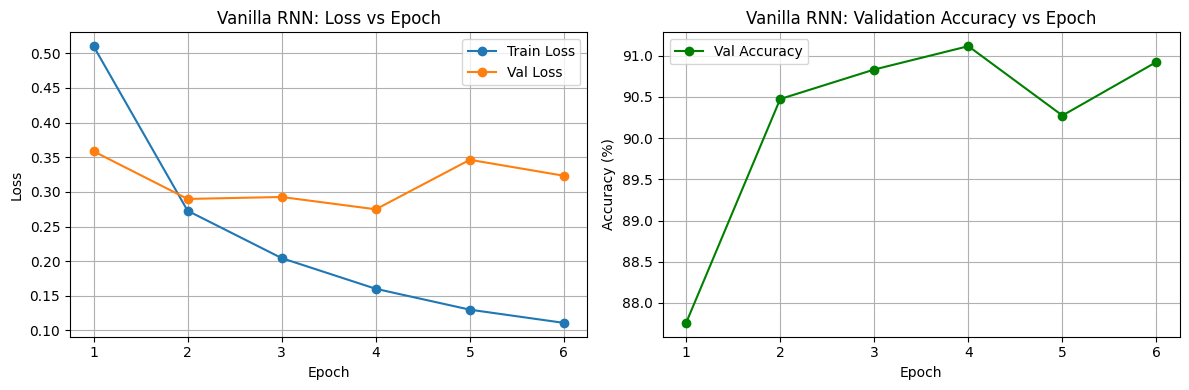

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, train_accuracies, val_losses, val_accuracies = train(model, optimizer, criterion, num_epochs, train_dataloader, val_dataloader)
plot_learning_curves(train_losses, val_losses, val_accuracies, "Vanilla RNN")

In [ ]:
test_accuracy, avg_test_loss, wrong_predictions = test_model(model, df_test)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')
print("Wrong Predictions (10 displayed): \n")
for i in range(min(len(wrong_predictions), 10)):
  print(f"Text: {wrong_predictions[i][0]}\nTrue Label: {wrong_predictions[i][1]}\nPredicted Label: {wrong_predictions[i][2].item()}\n")

Test Loss: 0.3962
Test Accuracy: 89.32%
Wrong Predictions (10 displayed): 

Text: IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.
True Label: 3
Predicted Label: 2

Text: Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped shoes for decades...
True Label: 3
Predicted Label: 2

Text: Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.
True Label: 0
Predicted Label: 1

Text: Intel to delay product aimed for high-definition TVs SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the launch of a video display chip it had previously planned to introduce by year end, putting off a showdown with Texas Instruments Inc. in the fast

# Task 2: Fine-tune a Pretrained Transformer

**1. Tokenization, padding, truncation, and attention masks**

In [ ]:
!pip install -q transformers datasets evaluate accelerate peft

import os
import time
import random
import numpy as np
import pandas as pd
import torch
import nltk
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, TaskType, get_peft_model
import evaluate

RANDOM_SEED = 2026
MODEL_NAME = "distilbert-base-uncased"
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}
LABEL2ID = {name: i for i, name in enumerate(LABEL_NAMES)}
DEFAULT_MAX_LENGTH = 128

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(RANDOM_SEED)

accuracy_metric = evaluate.load("accuracy")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Reuse the same split from Task 1 so the LSTM and Transformer comparisons are fair.
train_df_t2 = train_set.reset_index(drop=True).copy()
val_df_t2 = val_set.reset_index(drop=True).copy()
test_df_t2 = df_test.reset_index(drop=True).copy()

dataset_dict_raw = DatasetDict({
    "train": Dataset.from_pandas(train_df_t2, preserve_index=False),
    "validation": Dataset.from_pandas(val_df_t2, preserve_index=False),
    "test": Dataset.from_pandas(test_df_t2, preserve_index=False),
})

print(dataset_dict_raw)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


**Short Example**

In [ ]:
author_example = "OpenAI researchers are fine-tuning transformers efficiently."

word_tokens = nltk.word_tokenize(author_example.lower(), language="english", preserve_line=False)
subword_tokens = tokenizer.tokenize(author_example)
encoded_example = tokenizer(author_example, truncation=True, max_length=DEFAULT_MAX_LENGTH)

print("Original text:")
print(author_example)

print("\nTask 1 word-level tokens:")
print(word_tokens)

print("\nTask 2 transformer subword tokens:")
print(subword_tokens)

print("\nWhy they differ:")
print("The LSTM tokenizer splits mostly into whole words/punctuation, while DistilBERT splits into subwords and can represent rare words by reusing smaller pieces.")

print("\nEncoded example keys:", list(encoded_example.keys()))
print("input_ids:", encoded_example["input_ids"])
print("attention_mask:", encoded_example["attention_mask"])

Original text:
OpenAI researchers are fine-tuning transformers efficiently.

Task 1 word-level tokens:
['openai', 'researchers', 'are', 'fine-tuning', 'transformers', 'efficiently', '.']

Task 2 transformer subword tokens:
['open', '##ai', 'researchers', 'are', 'fine', '-', 'tuning', 'transformers', 'efficiently', '.']

Why they differ:
The LSTM tokenizer splits mostly into whole words/punctuation, while DistilBERT splits into subwords and can represent rare words by reusing smaller pieces.

Encoded example keys: ['input_ids', 'token_type_ids', 'attention_mask']
input_ids: [101, 2330, 4886, 6950, 2024, 2986, 1011, 17372, 19081, 18228, 1012, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


**Load Model**

In [ ]:
def tokenize_dataset_dict(dataset_dict, max_length):
    def preprocess_function(examples):
        return tokenizer(examples["text"], truncation=True, max_length=max_length)

    tokenized = dataset_dict.map(preprocess_function, batched=True)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    return tokenized, collator

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def build_transformer_model(mode="full", lora_r=8, lora_alpha=16, lora_dropout=0.1):
    # mode in {"full", "frozen", "lora"}
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=4,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    if mode == "full":
        pass
    elif mode == "frozen":
        for param in model.distilbert.parameters():
            param.requires_grad = False
    elif mode == "lora":
        peft_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["q_lin", "k_lin", "v_lin"],
            bias="none",
        )
        model = get_peft_model(model, peft_config)
    else:
        raise ValueError("mode must be one of: 'full', 'frozen', 'lora'")

    total_params, trainable_params = count_parameters(model)
    return model.to(device), total_params, trainable_params

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy_metric.compute(predictions=preds, references=labels)

def extract_history(trainer):
    history = {
        "train_epochs": [],
        "train_losses": [],
        "eval_epochs": [],
        "eval_losses": [],
        "eval_accuracies": [],
    }

    for log in trainer.state.log_history:
        if "loss" in log and "eval_loss" not in log:
            history["train_epochs"].append(log.get("epoch"))
            history["train_losses"].append(log["loss"])
        if "eval_loss" in log:
            history["eval_epochs"].append(log.get("epoch"))
            history["eval_losses"].append(log["eval_loss"])
            history["eval_accuracies"].append(log.get("eval_accuracy"))

    return history

def get_learning_rate_for_mode(mode):
    if mode == "full":
        return 2e-5
    if mode == "frozen":
        return 1e-3
    if mode == "lora":
        return 5e-4
    raise ValueError("Unknown mode")

def get_misclassified_examples(preds, labels, dataframe):
    examples = []
    for i in range(len(preds)):
        if preds[i] != labels[i]:
            examples.append({
                "text": dataframe.iloc[i]["text"],
                "true_label": ID2LABEL[int(labels[i])],
                "pred_label": ID2LABEL[int(preds[i])],
            })
    return examples

def train_transformer_experiment(
    run_name,
    mode="full",
    max_length=DEFAULT_MAX_LENGTH,
    num_epochs=3,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1,
):
    set_all_seeds(RANDOM_SEED)

    tokenized_datasets, data_collator = tokenize_dataset_dict(dataset_dict_raw, max_length=max_length)
    model, total_params, trainable_params = build_transformer_model(
        mode=mode,
        lora_r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
    )

    learning_rate = get_learning_rate_for_mode(mode)

    training_args = TrainingArguments(
        output_dir=f"./{run_name}",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=RANDOM_SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    start_time = time.perf_counter()
    trainer.train()
    train_wallclock_seconds = time.perf_counter() - start_time

    val_metrics = trainer.evaluate(tokenized_datasets["validation"])
    test_metrics = trainer.evaluate(tokenized_datasets["test"], metric_key_prefix="test")

    pred_output = trainer.predict(tokenized_datasets["test"])
    test_preds = np.argmax(pred_output.predictions, axis=1)
    test_labels = pred_output.label_ids
    misclassified_examples = get_misclassified_examples(test_preds, test_labels, test_df_t2)

    return {
        "run_name": run_name,
        "mode": mode,
        "max_length": max_length,
        "trainer": trainer,
        "history": extract_history(trainer),
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "misclassified_examples": misclassified_examples,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "learning_rate": learning_rate,
        "train_wallclock_seconds": train_wallclock_seconds,
        "lora_r": lora_r if mode == "lora" else None,
        "lora_alpha": lora_alpha if mode == "lora" else None,
        "lora_dropout": lora_dropout if mode == "lora" else None,
    }

def make_results_row(results, model_label):
    return {
        "model": model_label,
        "mode": results["mode"],
        "max_length": results["max_length"],
        "trainable_params": results["trainable_params"],
        "total_params": results["total_params"],
        "learning_rate": results["learning_rate"],
        "val_accuracy": results["val_metrics"].get("eval_accuracy"),
        "test_accuracy": results["test_metrics"].get("test_accuracy"),
        "val_loss": results["val_metrics"].get("eval_loss"),
        "test_loss": results["test_metrics"].get("test_loss"),
        "train_time_sec": results["train_wallclock_seconds"],
    }

def show_misclassified_examples(results, n_examples=5):
    print(f"\n{results['run_name']} -> misclassified test examples: {len(results['misclassified_examples'])}")
    for i, ex in enumerate(results["misclassified_examples"][:n_examples], start=1):
        print(f"\nExample {i}")
        print("True Label:", ex["true_label"])
        print("Predicted Label:", ex["pred_label"])
        print("Text:", ex["text"])

def plot_history(results, title_prefix):
    history = results["history"]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_epochs"], history["train_losses"], marker="o", label="Train loss")
    plt.plot(history["eval_epochs"], history["eval_losses"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history["eval_epochs"], history["eval_accuracies"], marker="o", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Validation accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

**Train Model**

In [ ]:
full_ft_results = train_transformer_experiment(
    run_name="distilbert_agnews_full_finetune",
    mode="full",
    max_length=128,
    num_epochs=3,
)

frozen_head_results = train_transformer_experiment(
    run_name="distilbert_agnews_frozen_encoder",
    mode="frozen",
    max_length=128,
    num_epochs=3,
)

lora_results = train_transformer_experiment(
    run_name="distilbert_agnews_lora",
    mode="lora",
    max_length=128,
    num_epochs=3,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1,
)

strategy_comparison_df = pd.DataFrame([
    make_results_row(full_ft_results, "DistilBERT full fine-tuning"),
    make_results_row(frozen_head_results, "DistilBERT frozen encoder + classifier head"),
    make_results_row(lora_results, "DistilBERT LoRA (PEFT)"),
])

for col in ["val_accuracy", "test_accuracy", "val_loss", "test_loss", "train_time_sec"]:
    strategy_comparison_df[col] = strategy_comparison_df[col].astype(float).round(4)

print(strategy_comparison_df.sort_values("test_accuracy", ascending=False))

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.237818,0.186102,0.938250
2,0.174658,0.175473,0.944750
3,0.142835,0.168091,0.946250


                                         model    mode  max_length  \
0                  DistilBERT full fine-tuning    full         128   
2                       DistilBERT LoRA (PEFT)    lora         128   
1  DistilBERT frozen encoder + classifier head  frozen         128   

   trainable_params  total_params  learning_rate  val_accuracy  test_accuracy  \
0          66956548      66956548        0.00002        0.9482         0.9467   
2            814852      67771400        0.00050        0.9462         0.9434   
1            593668      66956548        0.00100        0.9155         0.9141   

   val_loss  test_loss  train_time_sec  
0    0.2072     0.2183       1192.6801  
2    0.1681     0.1771        830.8392  
1    0.2353     0.2433        359.8374  


In [ ]:
# Misclassified examples for the primary Transformer model (full fine-tune)
show_misclassified_examples(full_ft_results, n_examples=10)


distilbert_agnews_full_finetune -> misclassified test examples: 405

Example 1
True Label: Sci/Tech
Predicted Label: Business
Text: IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.

Example 2
True Label: Sci/Tech
Predicted Label: Business
Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.

Example 3
True Label: Sci/Tech
Predicted Label: Business
Text: Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped shoes for 

In [ ]:
lstm_params = sum(p.numel() for p in model.parameters())

comparison_data = {
    "Model": [
        "LSTM (BiLSTM, scratch)",
        "DistilBERT (full fine-tune)",
        "DistilBERT (frozen encoder)",
        "DistilBERT (LoRA)",
    ],
    "Val Accuracy": [
        f"{val_accuracies[-1]:.2f}%",
        f"{full_ft_results['val_metrics']['eval_accuracy']*100:.2f}%",
        f"{frozen_head_results['val_metrics']['eval_accuracy']*100:.2f}%",
        f"{lora_results['val_metrics']['eval_accuracy']*100:.2f}%",
    ],
    "Test Accuracy": [
        f"{test_accuracy:.2f}%",
        f"{full_ft_results['test_metrics']['test_accuracy']*100:.2f}%",
        f"{frozen_head_results['test_metrics']['test_accuracy']*100:.2f}%",
        f"{lora_results['test_metrics']['test_accuracy']*100:.2f}%",
    ],
    "Total Params": [
        f"{lstm_params:,}",
        f"{full_ft_results['total_params']:,}",
        f"{frozen_head_results['total_params']:,}",
        f"{lora_results['total_params']:,}",
    ],
    "Trainable Params": [
        f"{lstm_params:,}",
        f"{full_ft_results['trainable_params']:,}",
        f"{frozen_head_results['trainable_params']:,}",
        f"{lora_results['trainable_params']:,}",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                      Model Val Accuracy Test Accuracy Total Params Trainable Params
     LSTM (BiLSTM, scratch)       90.92%        89.32%    7,224,324        7,224,324
DistilBERT (full fine-tune)       94.82%        94.67%   66,956,548       66,956,548
DistilBERT (frozen encoder)       91.55%        91.41%   66,956,548          593,668
          DistilBERT (LoRA)       94.62%        94.34%   67,771,400          814,852


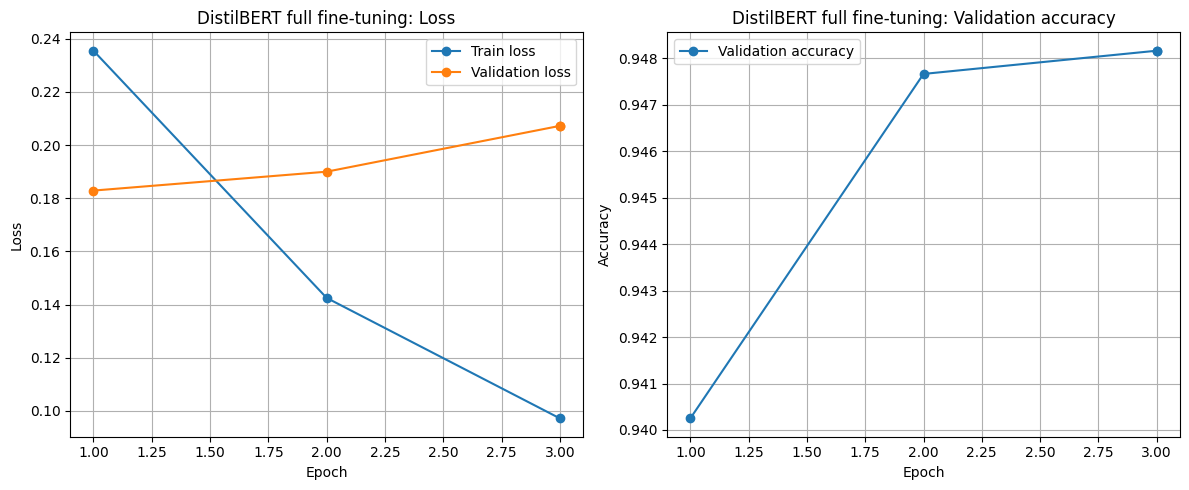

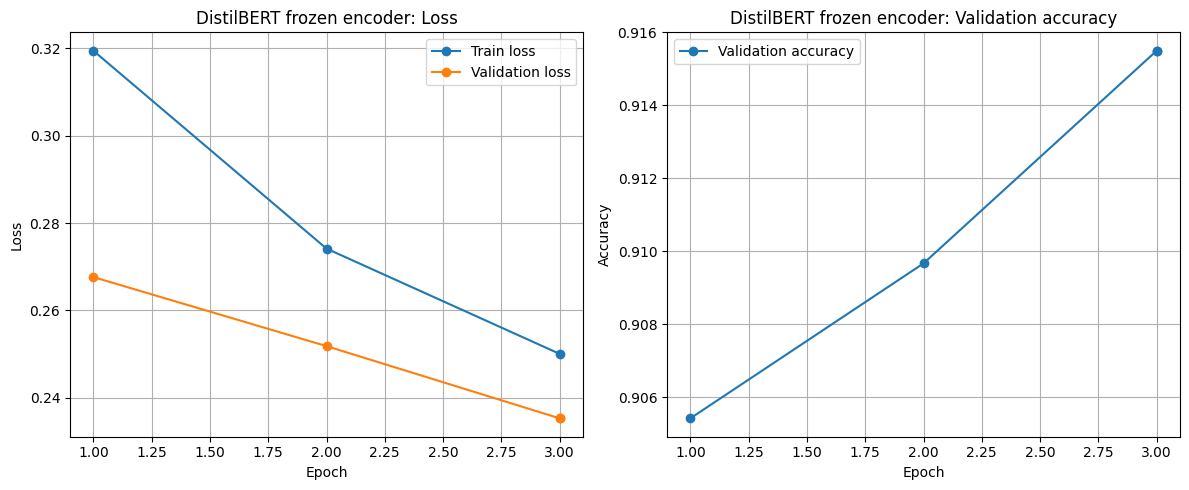

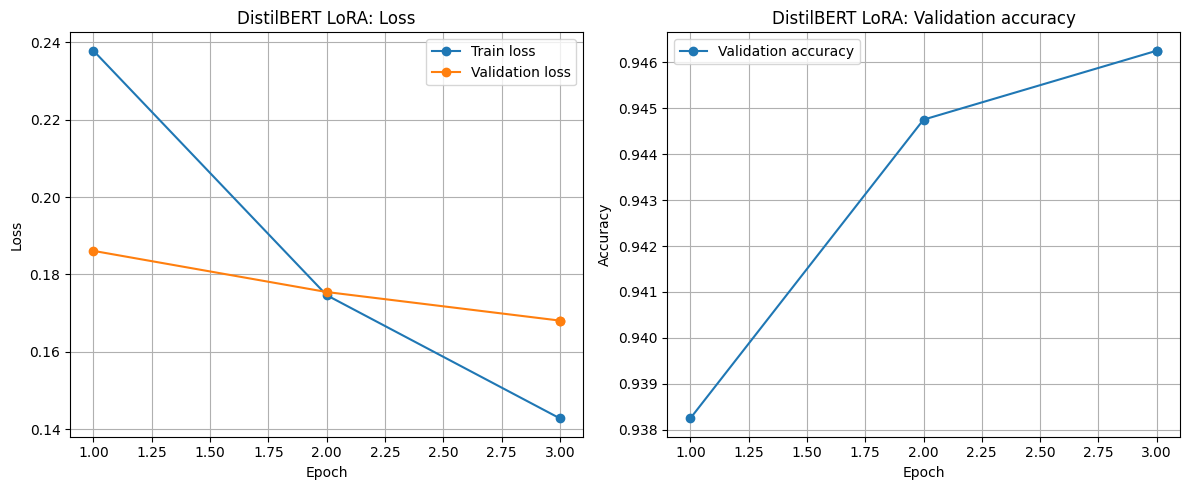

In [ ]:
plot_history(full_ft_results, "DistilBERT full fine-tuning")
plot_history(frozen_head_results, "DistilBERT frozen encoder")
plot_history(lora_results, "DistilBERT LoRA")

In [ ]:
length_sweep = [64, 128, 256]
length_results = []

for max_len in length_sweep:
    print(f"\nRunning LoRA experiment with max_length={max_len}")
    result = train_transformer_experiment(
        run_name=f"distilbert_lora_len_{max_len}",
        mode="lora",
        max_length=max_len,
        num_epochs=3,
        lora_r=8,
        lora_alpha=16,
        lora_dropout=0.1,
    )
    length_results.append(result)

length_comparison_df = pd.DataFrame([
    make_results_row(res, f"DistilBERT LoRA, Lmax={res['max_length']}")
    for res in length_results
])

for col in ["val_accuracy", "test_accuracy", "val_loss", "test_loss", "train_time_sec"]:
    length_comparison_df[col] = length_comparison_df[col].astype(float).round(4)

print(length_comparison_df.sort_values("max_length"))


Running LoRA experiment with max_length=64


Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.236399,0.185961,0.938583
2,0.173840,0.174171,0.944000
3,0.142022,0.169390,0.945833


                       model  mode  max_length  trainable_params  \
0   DistilBERT LoRA, Lmax=64  lora          64            814852   
1  DistilBERT LoRA, Lmax=128  lora         128            814852   
2  DistilBERT LoRA, Lmax=256  lora         256            814852   

   total_params  learning_rate  val_accuracy  test_accuracy  val_loss  \
0      67771400         0.0005        0.9438         0.9438    0.1731   
1      67771400         0.0005        0.9462         0.9434    0.1681   
2      67771400         0.0005        0.9458         0.9451    0.1694   

   test_loss  train_time_sec  
0     0.1790        730.1996  
1     0.1771        819.9098  
2     0.1722        847.1156  


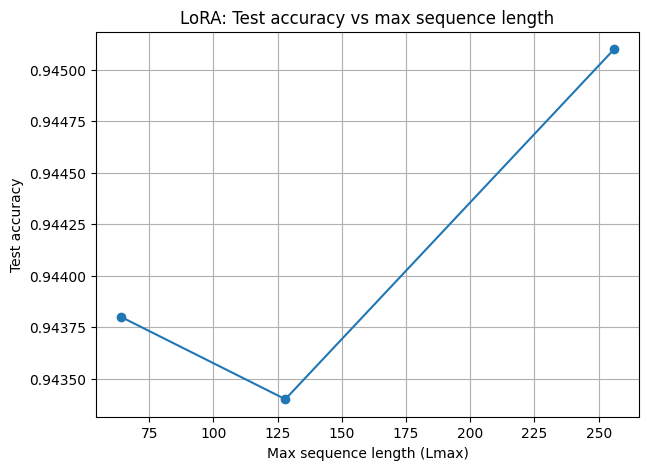

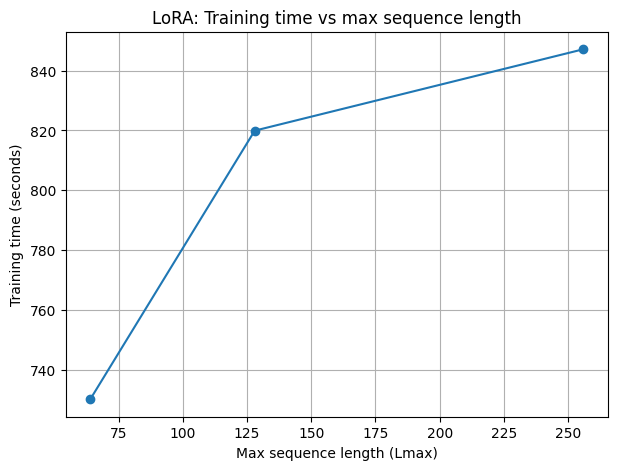

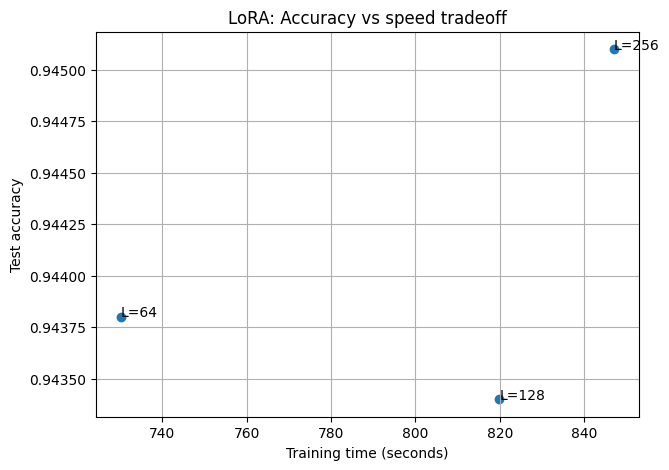

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(length_comparison_df["max_length"], length_comparison_df["test_accuracy"], marker="o")
plt.xlabel("Max sequence length (Lmax)")
plt.ylabel("Test accuracy")
plt.title("LoRA: Test accuracy vs max sequence length")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(length_comparison_df["max_length"], length_comparison_df["train_time_sec"], marker="o")
plt.xlabel("Max sequence length (Lmax)")
plt.ylabel("Training time (seconds)")
plt.title("LoRA: Training time vs max sequence length")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(length_comparison_df["train_time_sec"], length_comparison_df["test_accuracy"])
for _, row in length_comparison_df.iterrows():
    plt.annotate(f"L={int(row['max_length'])}", (row["train_time_sec"], row["test_accuracy"]))
plt.xlabel("Training time (seconds)")
plt.ylabel("Test accuracy")
plt.title("LoRA: Accuracy vs speed tradeoff")
plt.grid(True)
plt.show()

In [ ]:
show_misclassified_examples(full_ft_results, n_examples=5)
show_misclassified_examples(frozen_head_results, n_examples=5)
show_misclassified_examples(lora_results, n_examples=5)

best_strategy = strategy_comparison_df.sort_values("test_accuracy", ascending=False).iloc[0]
best_length = length_comparison_df.sort_values("test_accuracy", ascending=False).iloc[0]

print("\nBest overall Transformer strategy:")
print(best_strategy[["model", "test_accuracy", "trainable_params", "train_time_sec"]])

print("\nBest max-length setting from the LoRA sweep:")
print(best_length[["model", "max_length", "test_accuracy", "train_time_sec"]])


distilbert_agnews_full_finetune -> misclassified test examples: 405

Example 1
True Label: Sci/Tech
Predicted Label: Business
Text: IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.

Example 2
True Label: Sci/Tech
Predicted Label: Business
Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.

Example 3
True Label: Sci/Tech
Predicted Label: Business
Text: Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped shoes for 